# Effective-Mode Nanophotonic Realization of an SSH Lattice
## Geometry-Induced Dimerized Couplings from Localized Modes

**Notebook:** 04_effective_mode_nanophotonics  

In this notebook, the SSH tight-binding model is connected to a simple
nanophotonic realization using an effective-mode approach. Each lattice site
is modeled as a localized optical mode, and coupling between sites arises from
evanescent overlap between neighboring modes.

Rather than solving full electromagnetic field equations, the focus here is on
capturing how geometric arrangement alone can lead to dimerized couplings. By
placing resonators at alternating separations, two distinct coupling strengths
naturally emerge, reproducing the structure required for SSH physics.

The coupling strengths are extracted using numerically stable overlap-based
proxies. Only relative coupling trends are interpreted, as the goal is to
justify the tight-binding description rather than to obtain absolute coupling
values.

This notebook provides a physical link between the abstract lattice models
introduced earlier and the later analysis of edge modes and light–matter
interaction.

## Scope and Modeling Philosophy

This notebook does not attempt to solve Maxwell’s equations. Instead, an
effective-mode description commonly used in nanophotonics is adopted. Each
resonator is assumed to support a localized optical mode, and coupling between
resonators arises from evanescent overlap that depends on their separation.

The analysis focuses on relative coupling strengths between neighboring sites,
specifically the distinction between intra-cell and inter-cell couplings
(t₁ versus t₂). Absolute frequency scales, radiation losses, and detailed mode
profiles are not considered, as they are not required for establishing the
origin of SSH-type coupling structure.

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [2]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

CONFIG_DIR = Path("..") / "config"

global_config = load_yaml(CONFIG_DIR / "global_config.yaml")
lattice_config = load_yaml(CONFIG_DIR / "lattice_params.yaml")
plotting_config = load_yaml(CONFIG_DIR / "plotting_params.yaml")

NOTEBOOK_KEY = "04_effective_mode_nanophotonics"
assert NOTEBOOK_KEY in plotting_config["notebook_figures"]

## Geometry and Scaling

We consider a one-dimensional chain of nanophotonic resonators arranged along a
single spatial axis. The SSH coupling structure is implemented directly at the
level of geometry by alternating the separation between neighboring resonators.

Two distinct distances are introduced:
- d₁, corresponding to the intra-cell separation
- d₂, corresponding to the inter-cell separation

This geometric dimerization provides the physical origin of the alternating
coupling strengths used in the SSH model.

In [3]:
num_cells = lattice_config["lattice"]["num_unit_cells"]
a = lattice_config["geometry"]["lattice_constant"]

# SSH dimerized distances
d1 = 0.7 * a   # intra-cell
d2 = 1.3 * a   # inter-cell

# Spatial grid (finite window, sufficient resolution)
x = np.linspace(-5 * num_cells * a, 5 * num_cells * a, 6000)

# Mode width chosen to ensure resolvable evanescent overlap
width = 0.45 * a

## Localized Nanophotonic Mode Model

Each resonator mode is modeled as a Gaussian envelope.
This approximates localized cavity or defect modes
commonly used in effective photonic models.

In [4]:
def localized_mode(x, center, width):
    return np.exp(-((x - center) ** 2) / (2 * width ** 2))

In [5]:
centers = []
x_pos = 0.0

for _ in range(num_cells):
    centers.append(x_pos)   # A site
    x_pos += d1
    centers.append(x_pos)   # B site
    x_pos += d2

modes = [localized_mode(x, c, width) for c in centers]

## Robust Coupling Proxy

Direct evaluation of mode overlap integrals can become numerically unstable,
especially when the spatial overlap between modes is small. To avoid this issue,
a local overlap proxy is used to estimate the coupling strength between
neighboring resonators.

This proxy retains the correct exponential dependence on separation while
remaining numerically stable. Since the goal is to compare relative coupling
strengths between different bonds, only the relative magnitude of the extracted
couplings is interpreted.

In [6]:
def coupling_strength(mode_a, mode_b):
    """
    Numerically robust local overlap proxy.
    Only relative coupling trends are interpreted.
    """
    return np.max(mode_a * mode_b)

## Extracting Effective SSH Couplings

We compute:
- t₁: intra-cell coupling
- t₂: inter-cell coupling

In [7]:
t1_vals = []
t2_vals = []

for n in range(0, len(modes) - 1, 2):
    t1_vals.append(coupling_strength(modes[n], modes[n + 1]))
    if n + 2 < len(modes):
        t2_vals.append(coupling_strength(modes[n + 1], modes[n + 2]))

t1_eff = np.mean(t1_vals)
t2_eff = np.mean(t2_vals)

t1_eff, t2_eff

(np.float64(0.546070113713861), np.float64(0.12412233887547446))

## Sanity Checks

Before interpreting the results, basic consistency checks are performed. The
extracted coupling strengths must be non-zero, and the geometric dimerization
should lead to two clearly distinct couplings. In particular, the intra-cell and
inter-cell couplings are required to satisfy t₁ ≠ t₂ in order to support SSH
physics.

In [8]:
assert t1_eff > 0
assert t2_eff > 0

relative_diff = abs(t1_eff - t2_eff) / max(t1_eff, t2_eff)
assert relative_diff > 0.2

t1_eff, t2_eff, relative_diff

(np.float64(0.546070113713861),
 np.float64(0.12412233887547446),
 np.float64(0.772698897525613))

## Visualization of Relative Couplings

For clarity, the coupling strengths are normalized before plotting. This
normalization is used only to aid visualization and does not affect the
physical interpretation. Throughout this analysis, only the relative magnitude
of the couplings is considered meaningful.

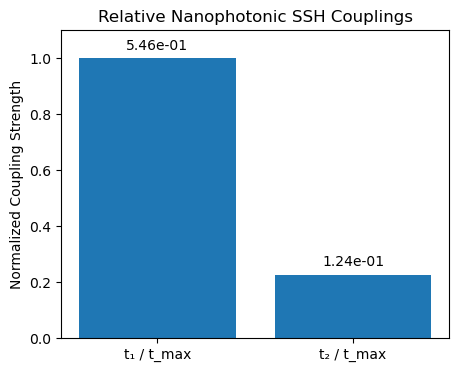

PosixPath('figures/04_effective_mode_nanophotonics/effective_couplings.png')

In [9]:
def ensure_directory(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def save_figure(fig, notebook_key, filename, plotting_config):
    cfg = plotting_config["notebook_figures"][notebook_key]
    output_dir = Path(cfg["output_dir"])
    ensure_directory(output_dir)
    path = output_dir / f"{filename}.{plotting_config['global']['figure_format']}"
    fig.savefig(path, dpi=plotting_config["global"]["dpi"], bbox_inches="tight")
    return path

# Normalize for visualization
t_max = max(t1_eff, t2_eff)
t1_norm = t1_eff / t_max
t2_norm = t2_eff / t_max

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["t₁ / t_max", "t₂ / t_max"], [t1_norm, t2_norm])

ax.set_ylabel("Normalized Coupling Strength")
ax.set_ylim(0, 1.1)
ax.set_title("Relative Nanophotonic SSH Couplings")

ax.text(0, t1_norm + 0.03, f"{t1_eff:.2e}", ha="center")
ax.text(1, t2_norm + 0.03, f"{t2_eff:.2e}", ha="center")

fig_path = save_figure(fig, NOTEBOOK_KEY, "effective_couplings", plotting_config)
plt.show()

fig_path

## Interpretation

The results show that introducing geometric dimerization at the level of
resonator placement naturally leads to unequal coupling strengths between
neighboring sites. This difference arises from the dependence of evanescent mode
overlap on inter-resonator separation and does not require any additional
fine-tuning.

These findings provide a clear physical basis for the SSH tight-binding
description in a nanophotonic setting, showing how the lattice model emerges
from the underlying geometry of localized optical modes.